In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Učitavanje podataka**

U ovoj fazi učitava se Boston Housing dataset koji sadrži socio-ekonomske i geografske karakteristike područja Bostona.
Cilj analize je predvidjeti srednju vrijednost kuća (MEDV) na temelju dostupnih ulaznih varijabli. 
Nakon učitavanja podataka provjerava se njihova struktura, prisutnost nedostajućih vrijednosti te osnovne statističke karakteristike.

In [2]:
df = pd.read_csv("boston.csv") 
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df = df.copy()

# Provjera missing vrijednosti
print("Missing values po kolonama:")
print(df.isnull().sum())

# Osnovna statistika
print("\nOpis podataka:")
display(df.describe().round(2))

# Target varijabla
target = "MEDV"

print("\nStatistika target varijable (cijena kuća):")
print(df[target].describe().round(2))

Missing values po kolonama:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Opis podataka:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00



Statistika target varijable (cijena kuća):
count    506.00
mean      22.53
std        9.20
min        5.00
25%       17.02
50%       21.20
75%       25.00
max       50.00
Name: MEDV, dtype: float64


**Eksplorativna analiza podataka**

U ovoj fazi provedena je eksplorativna analiza podataka kako bi se razumjela struktura dataset-a. Analizirane su osnovne statistike, distribucija ciljane varijable te međusobni odnosi između varijabli.

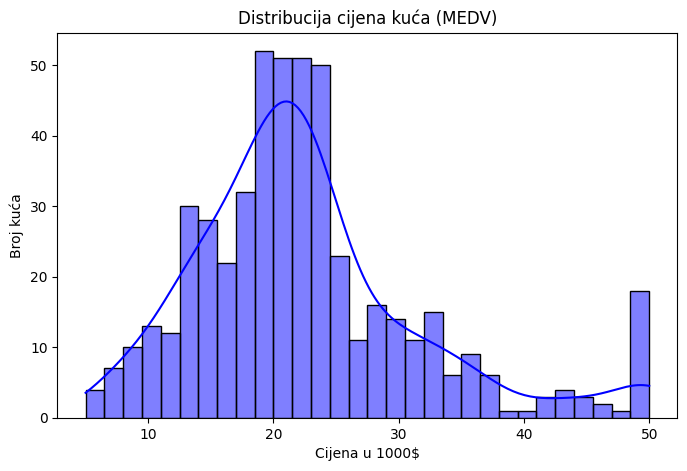

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["MEDV"], bins=30, kde=True, color="blue")
plt.title("Distribucija cijena kuća (MEDV)")
plt.xlabel("Cijena u 1000$")
plt.ylabel("Broj kuća")
plt.show()

print(df["MEDV"].describe())

Statistički prikaz varijable MEDV pokazuje da je prosječna vrijednost kuća 22.53 (u tisućama dolara), dok se većina vrijednosti nalazi između 17 i 25. Histogram potvrđuje blago asimetričnu distribuciju s prisutnim višim vrijednostima (outlierima) do 50.

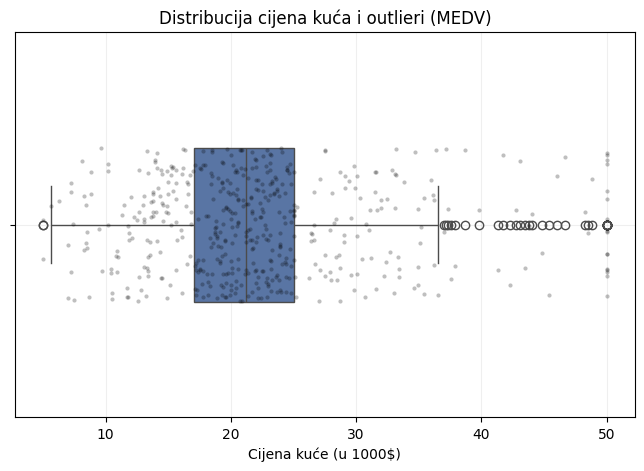

Broj outliera: 40


In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["MEDV"],
    color="#4C72B0",
    width=0.4
)

sns.stripplot(
    x=df["MEDV"],
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Distribucija cijena kuća i outlieri (MEDV)", fontsize=12)
plt.xlabel("Cijena kuće (u 1000$)")
plt.grid(alpha=0.2)

plt.show()


Q1 = df["MEDV"].quantile(0.25)
Q3 = df["MEDV"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["MEDV"] < Q1 - 1.5 * IQR) | (df["MEDV"] > Q3 + 1.5 * IQR)]

print("Broj outliera:", len(outliers))

Varijabla MEDV sadrži 40 outliera koji odstupaju od tipične distribucije cijena kuća.
Većina ekstremnih vrijednosti nalazi se na gornjoj granici (50.0), što upućuje na moguće cenzuriranje podataka.
Prisutan je i manji broj vrlo niskih vrijednosti.
Ovakva distribucija pokazuje asimetriju ciljane varijable, što opravdava korištenje transformacija i robusnih modela strojnog učenja.

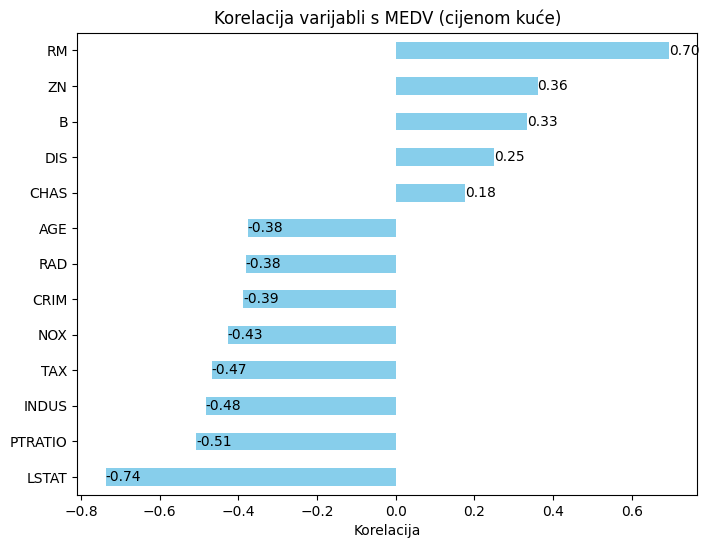

LSTAT     -0.737663
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
CHAS       0.175260
DIS        0.249929
B          0.333461
ZN         0.360445
RM         0.695360
MEDV       1.000000
Name: MEDV, dtype: float64


In [6]:
plt.figure(figsize=(8,6))

corr_target = df.corr(numeric_only=True)["MEDV"].sort_values()
corr_target = corr_target.drop("MEDV")

ax = corr_target.plot(kind="barh", color="skyblue")

# dodavanje vrijednosti na graf
for i, v in enumerate(corr_target):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.title("Korelacija varijabli s MEDV (cijenom kuće)")
plt.xlabel("Korelacija")
plt.show()

corr_target = df.corr(numeric_only=True)["MEDV"].sort_values()

print(corr_target)

Najjači utjecaj na cijenu kuće imaju LSTAT (negativan) i RM (pozitivan), dok ostale varijable imaju umjeren ili slab utjecaj na MEDV.

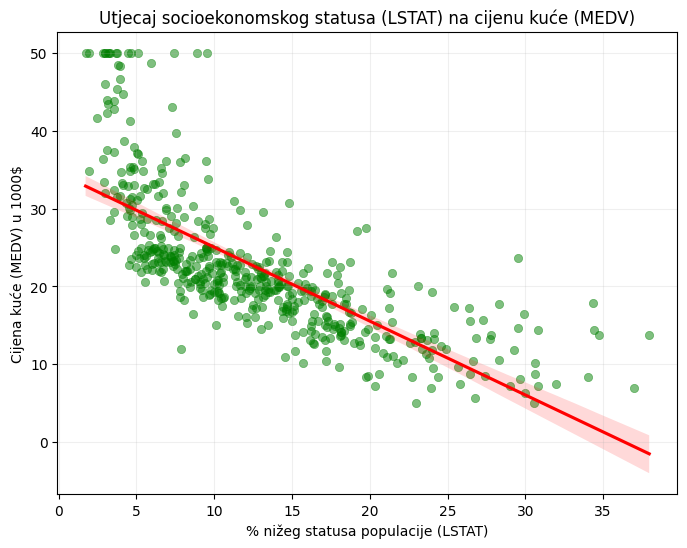

,count,mean,std,min,25%,50%,75%,max
LSTAT,506.0,12.653063,7.141062,1.73,6.950,11.36,16.955,37.97
MEDV,506.0,22.532806,9.197104,5.00,17.025,21.20,25.000,50.00


In [7]:
plt.figure(figsize=(8,6))

# Scatter (podaci)
sns.scatterplot(
    x=df["LSTAT"],
    y=df["MEDV"],
    alpha=0.5,
    color="green",
    edgecolor=None
)

# Trend linija
sns.regplot(
    x=df["LSTAT"],
    y=df["MEDV"],
    scatter=False,
    color="red"
)

plt.title("Utjecaj socioekonomskog statusa (LSTAT) na cijenu kuće (MEDV)", fontsize=12)
plt.xlabel("% nižeg statusa populacije (LSTAT)")
plt.ylabel("Cijena kuće (MEDV) u 1000$")
plt.grid(alpha=0.2)

plt.show()
summary = df[["LSTAT", "MEDV"]].describe().T
summary

Tablica prikazuje osnovne statistike za LSTAT i MEDV. MEDV ima širok raspon vrijednosti (5–50), 
dok LSTAT pokazuje značajnu varijabilnost. Podaci ukazuju na raznoliku strukturu i odnos između varijabli.

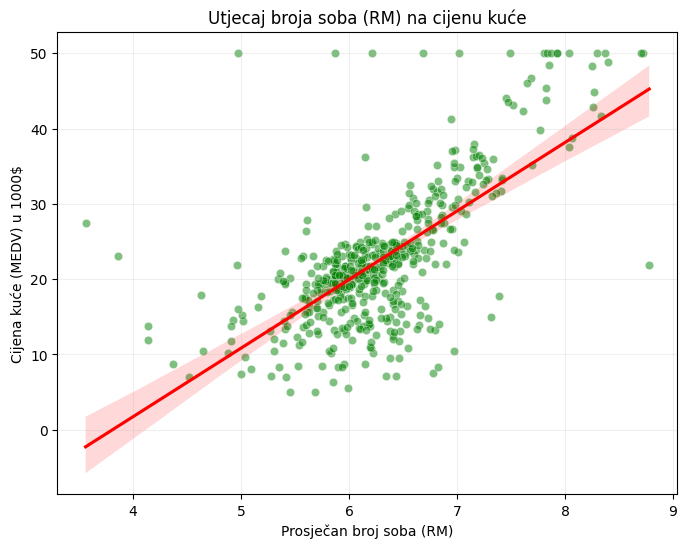

,count,mean,std,min,25%,50%,75%,max
RM,506.0,6.284634,0.702617,3.561,5.8855,6.2085,6.6235,8.78
MEDV,506.0,22.532806,9.197104,5.000,17.0250,21.2000,25.0000,50.00


In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["RM"],
    y=df["MEDV"],
    alpha=0.5,
    color="green"
)

sns.regplot(
    x=df["RM"],
    y=df["MEDV"],
    scatter=False,
    color="red"
)

plt.title("Utjecaj broja soba (RM) na cijenu kuće")
plt.xlabel("Prosječan broj soba (RM)")
plt.ylabel("Cijena kuće (MEDV) u 1000$")
plt.grid(alpha=0.2)

plt.show()
summary = df[["RM", "MEDV"]].describe().T
summary

Graf prikazuje pozitivnu vezu između broja soba i cijene kuće. Veći broj soba općenito znači višu cijenu nekretnine.

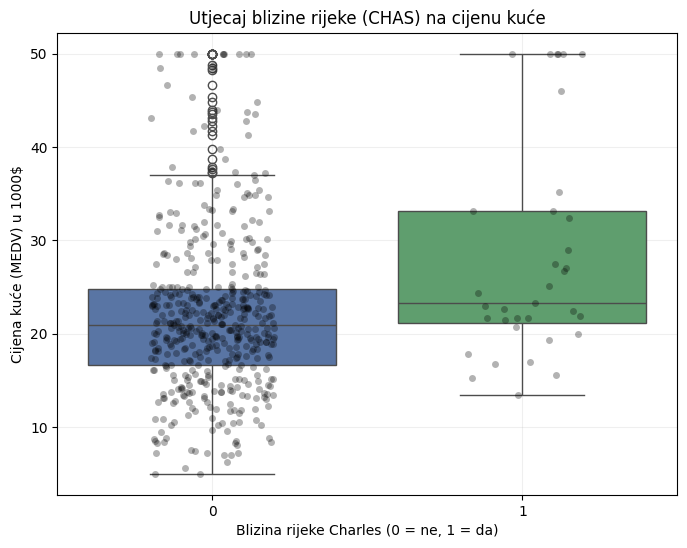

Statistika MEDV po CHAS grupama:



,count,mean,std,min,25%,50%,75%,max
CHAS,506.0,0.069170,0.253994,0.0,0.000,0.0,0.0,1.0
MEDV,506.0,22.532806,9.197104,5.0,17.025,21.2,25.0,50.0


In [9]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df["CHAS"],
    y=df["MEDV"],
    palette=["#4C72B0", "#55A868"]
)

sns.stripplot(
    x=df["CHAS"],
    y=df["MEDV"],
    color="black",
    alpha=0.3,
    jitter=0.2
)

plt.title("Utjecaj blizine rijeke (CHAS) na cijenu kuće", fontsize=12)
plt.xlabel("Blizina rijeke Charles (0 = ne, 1 = da)")
plt.ylabel("Cijena kuće (MEDV) u 1000$")
plt.grid(alpha=0.2)

plt.show()
print("Statistika MEDV po CHAS grupama:\n")
summary = df[["CHAS", "MEDV"]].describe().T
summary

Graf prikazuje raspodjelu cijena kuća u odnosu na blizinu rijeke Charles. Kuće koje se nalaze uz rijeku (CHAS = 1) u prosjeku imaju nešto više cijene u odnosu na one koje nisu u blizini rijeke.

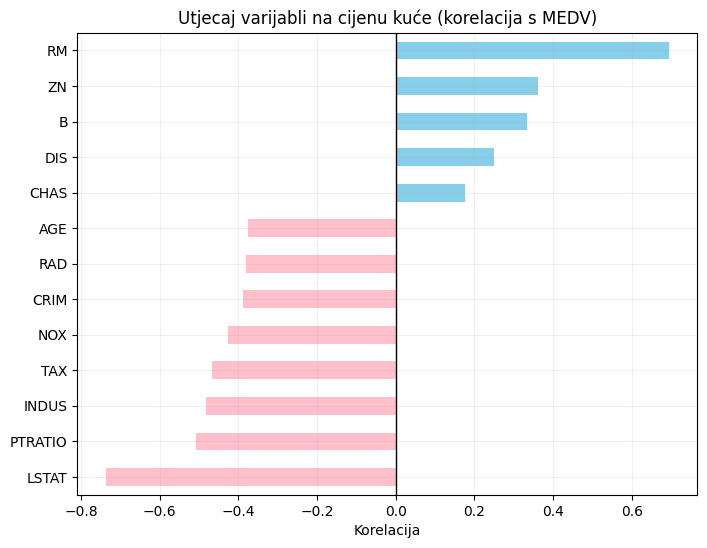

,Varijabla,Korelacija s MEDV
0,LSTAT,-0.737663
1,PTRATIO,-0.507787
2,INDUS,-0.483725
3,TAX,-0.468536
4,NOX,-0.427321
5,CRIM,-0.388305
6,RAD,-0.381626
7,AGE,-0.376955
8,CHAS,0.175260
9,DIS,0.249929


In [10]:
corr_target = df.corr(numeric_only=True)["MEDV"].sort_values()

plt.figure(figsize=(8,6))

colors = ["pink" if x < 0 else "skyblue" for x in corr_target.drop("MEDV")]

corr_target.drop("MEDV").plot(
    kind="barh",
    color=colors
)

plt.title("Utjecaj varijabli na cijenu kuće (korelacija s MEDV)", fontsize=12)
plt.xlabel("Korelacija")
plt.axvline(0, color="black", linewidth=1)

plt.grid(alpha=0.2)

plt.show()

corr_target = df.corr(numeric_only=True)["MEDV"].sort_values()
corr_table = corr_target.reset_index()
corr_table.columns = ["Varijabla", "Korelacija s MEDV"]

corr_table

Tablica prikazuje korelaciju svih varijabli s cijenom kuća (MEDV). Najjači pozitivni utjecaj ima RM, dok LSTAT ima najjači negativni utjecaj. Ovi rezultati pokazuju da broj soba i socioekonomski status imaju najveći utjecaj na cijenu nekretnina.

**Machine Learning modeli**

U ovom dijelu projekta podaci se pripremaju za treniranje modela strojnog učenja.
Dataset se dijeli na trening i testni skup kako bi se mogla objektivno procijeniti sposobnost generalizacije modela na nepoznatim podacima. 
Također se provodi standardizacija atributa za modele osjetljive na skalu podataka.

In [11]:
from sklearn.model_selection import train_test_split
# Ulazne varijable (features)
X = df.drop("MEDV", axis=1)

# Ciljna varijabla (target)
y = df["MEDV"]

# Podjela na train i test skup
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (404, 13)
Test shape: (102, 13)


In [12]:
from sklearn.preprocessing import StandardScaler
# Standardizacija podataka
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Skaliranje završeno.")

Skaliranje završeno.


Podaci su podijeljeni na trening i testni skup u omjeru 80:20 
Standardizacija je primijenjena kako bi varijable bile na sličnoj skali, što je posebno važno za linearne modele i neuronske mreže

**Ridge regresija**
Ridge regresija predstavlja linearni model s L2 regularizacijom. 
Koristi se kao osnovni referentni model (baseline) za usporedbu s naprednijim nelinearnim algoritmima strojnog učenja.

In [13]:
# Ridge model
ridge = Ridge(alpha=1.0)

# Treniranje modela
ridge.fit(X_train_scaled, y_train)

# Predikcije
ridge_pred = ridge.predict(X_test_scaled)

print("Ridge model treniran.")

Ridge model treniran.


In [14]:
#Evaluacija modela
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

ridge_results = pd.DataFrame({
    "Metrika": ["RMSE", "MAE", "R²"],
    "Vrijednost": [ridge_rmse, ridge_mae, ridge_r2]
})

ridge_results

,Metrika,Vrijednost
0,RMSE,4.930812
1,MAE,3.185724
2,R²,0.668462


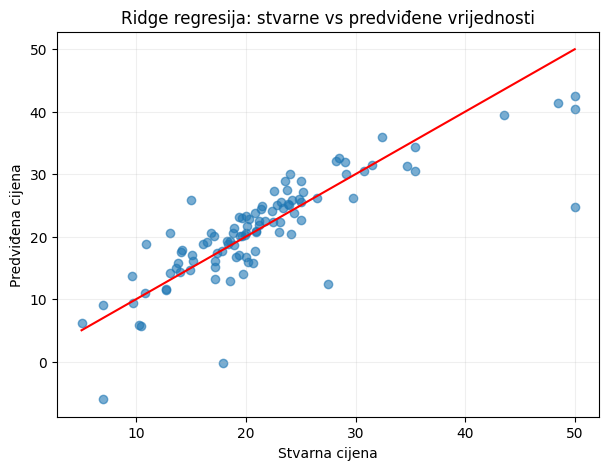

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, ridge_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Stvarna cijena")
plt.ylabel("Predviđena cijena")
plt.title("Ridge regresija: stvarne vs predviđene vrijednosti")

plt.grid(alpha=0.2)
plt.show()

Graf prikazuje usporedbu stvarnih i predviđenih vrijednosti cijena kuća pomoću Ridge regresije. 
Većina točaka prati idealnu dijagonalu, ali se uočavaju odstupanja kod ekstremnijih vrijednosti, što ukazuje na ograničenja linearnog modela.

**Random Forest model**

In [16]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
mae = mean_absolute_error(y_test, rf_pred)
r2 = r2_score(y_test, rf_pred)

results = pd.DataFrame({
    "Model": ["Random Forest"],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2]
})

results

,Model,RMSE,MAE,R2
0,Random Forest,2.946946,2.041679,0.881576


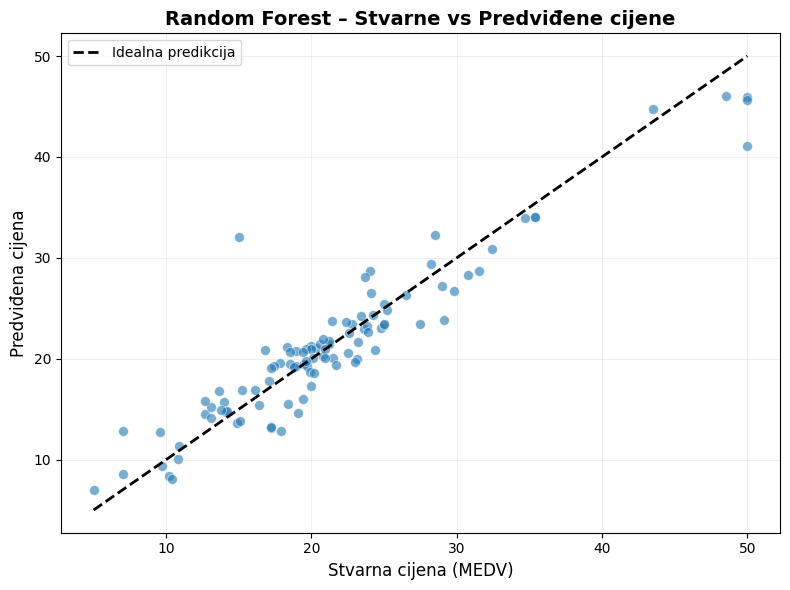

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=rf_pred,
    alpha=0.6,
    s=50,
    palette="viridis"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Idealna predikcija"
)

plt.title("Random Forest – Stvarne vs Predviđene cijene", fontsize=14, fontweight="bold")
plt.xlabel("Stvarna cijena (MEDV)", fontsize=12)
plt.ylabel("Predviđena cijena", fontsize=12)

plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()

plt.show()

Random Forest model pokazuje dobru aproksimaciju stvarnih cijena kuća.
Većina predikcija prati dijagonalnu liniju, što znači da model uspješno hvata odnos između ulaznih varijabli i cijene.